In [1]:
# Colab setup
# Do NOT install/downgrade TensorFlow. Colab's current TensorFlow is used.
!pip -q install -U scikeras scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.1 MB/s eta 0:00:00


In [2]:
# Restart the runtime automatically after package installation if needed.
# IMPORTANT: If Colab displays a message saying the runtime must restart,
# choose "Restart session", then use Runtime -> Run all.
import sys
print("Python version:", sys.version)

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [3]:
# Imports — run this after the runtime has restarted
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import scikeras
import tensorflow as tf

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from scikeras.wrappers import KerasClassifier

from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
keras.utils.set_random_seed(42)

print("scikit-learn:", sklearn.__version__)
print("SciKeras:", scikeras.__version__)
print("TensorFlow:", tf.__version__)

scikit-learn: 1.9.1
SciKeras: 0.13.0
TensorFlow: 2.20.0


## Task 1 — Data Acquisition and Loading

In [4]:
# Pima Indians Diabetes dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print("Dataset shape:", df.shape)
display(df.head())
print("\nDataset information:")
df.info()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Check missing values and target distribution
print("Missing values:")
display(df.isnull().sum())

print("\nOutcome distribution:")
display(df["Outcome"].value_counts())

Missing values:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Outcome distribution:


,count
Outcome,
0,500
1,268


## Task 2 — Data Preprocessing

For medical measurements where zero is not meaningful, zero values are replaced with the median of the non-zero observations. The data is then split into training and testing sets and standardized.

In [6]:
zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df_clean = df.copy()

for col in zero_as_missing:
    median_value = df_clean.loc[df_clean[col] != 0, col].median()
    df_clean[col] = df_clean[col].replace(0, median_value)

X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


## Task 3 — Deep Learning Grid Search

In [7]:
# Function used by SciKeras to construct the Keras model
def create_model(
    learning_rate=0.001,
    kernel_initializer="glorot_uniform",
    activation="relu",
    dropout_rate=0.0,
    neurons=16
):
    K.clear_session()

    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(
            neurons,
            activation=activation,
            kernel_initializer=kernel_initializer
        ),
        Dropout(dropout_rate),
        Dense(
            1,
            activation="sigmoid"
        )
    ])

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [8]:
# SciKeras wrapper
model = KerasClassifier(
    model=create_model,
    verbose=0,
    random_state=42
)

# Compact but complete grid covering every parameter required by the assignment
param_grid = {
    "batch_size": [16, 32],
    "epochs": [20, 40],
    "model__learning_rate": [0.001, 0.01],
    "model__kernel_initializer": ["glorot_uniform", "he_uniform"],
    "model__activation": ["relu", "tanh"],
    "model__dropout_rate": [0.0, 0.2],
    "model__neurons": [16, 32]
}

print("Parameters being tuned:")
for parameter, values in param_grid.items():
    print(parameter, ":", values)

print("\nTotal parameter combinations:", np.prod([len(v) for v in param_grid.values()]))
print("With 3-fold CV, the search trains 384 model configurations.")

Parameters being tuned:
batch_size : [16, 32]
epochs : [20, 40]
model__learning_rate : [0.001, 0.01]
model__kernel_initializer : ['glorot_uniform', 'he_uniform']
model__activation : ['relu', 'tanh']
model__dropout_rate : [0.0, 0.2]
model__neurons : [16, 32]

Total parameter combinations: 128
With 3-fold CV, the search trains 384 model configurations.


In [9]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=1,
    verbose=2
)

grid_result = grid.fit(X_train, y_train)

print("\nGrid Search completed.")
print("Best cross-validation accuracy:", grid_result.best_score_)
print("\nBest parameters:")

for key, value in grid_result.best_params_.items():
    print(f"{key}: {value}")

Fitting 3 folds for each of 128 candidates, totalling 384 fits
[CV] END batch_size=16, epochs=20, model__activation=relu, model__dropout_rate=0.0, model__kernel_initializer=glorot_uniform, model__learning_rate=0.001, model__neurons=16; total time=  17.6s
[CV] END batch_size=16, epochs=20, model__activation=relu, model__dropout_rate=0.0, model__kernel_initializer=glorot_uniform, model__learning_rate=0.001, model__neurons=16; total time=   3.8s
[CV] END batch_size=16, epochs=20, model__activation=relu, model__dropout_rate=0.0, model__kernel_initializer=glorot_uniform, model__learning_rate=0.001, model__neurons=16; total time=   5.0s
[CV] END batch_size=16, epochs=20, model__activation=relu, model__dropout_rate=0.0, model__kernel_initializer=glorot_uniform, model__learning_rate=0.001, model__neurons=32; total time=   3.8s
[CV] END batch_size=16, epochs=20, model__activation=relu, model__dropout_rate=0.0, model__kernel_initializer=glorot_uniform, model__learning_rate=0.001, model__neurons=

[CV] END batch_size=32, epochs=20, model__activation=relu, model__dropout_rate=0.0, model__kernel_initializer=glorot_uniform, model__learning_rate=0.001, model__neurons=16; total time=   4.3s


[CV] END batch_size=32, epochs=20, model__activation=relu, model__dropout_rate=0.0, model__kernel_initializer=glorot_uniform, model__learning_rate=0.001, model__neurons=16; total time=   3.6s
[CV] END batch_size=32, epochs=20, model__activation=relu, model__dropout_rate=0.0, model__kernel_initializer=glorot_uniform, model__learning_rate=0.001, model__neurons=32; total time=   3.6s
[CV] END batch_size=32, epochs=20, model__activation=relu, model__dropout_rate=0.0, model__kernel_initializer=glorot_uniform, model__learning_rate=0.001, model__neurons=32; total time=   4.4s
[CV] END batch_size=32, epochs=20, model__activation=relu, model__dropout_rate=0.0, model__kernel_initializer=glorot_uniform, model__learning_rate=0.001, model__neurons=32; total time=   3.6s
[CV] END batch_size=32, epochs=20, model__activation=relu, model__dropout_rate=0.0, model__kernel_initializer=glorot_uniform, model__learning_rate=0.01, model__neurons=16; total time=   3.6s
[CV] END batch_size=32, epochs=20, model_

## Top Grid Search Results

In [10]:
results = pd.DataFrame(grid_result.cv_results_)

top_results = (
    results[
        ["mean_test_score", "std_test_score", "params"]
    ]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)

display(top_results)

,mean_test_score,std_test_score,params
30,0.788315,0.018404,"{'batch_size': 16, 'epochs': 20, 'model__activ..."
94,0.786697,0.027633,"{'batch_size': 32, 'epochs': 20, 'model__activ..."
58,0.786665,0.009601,"{'batch_size': 16, 'epochs': 40, 'model__activ..."
82,0.785055,0.017837,"{'batch_size': 32, 'epochs': 20, 'model__activ..."
49,0.785023,0.006669,"{'batch_size': 16, 'epochs': 40, 'model__activ..."
26,0.783429,0.019644,"{'batch_size': 16, 'epochs': 20, 'model__activ..."
17,0.783389,0.006010,"{'batch_size': 16, 'epochs': 20, 'model__activ..."
86,0.781803,0.019210,"{'batch_size': 32, 'epochs': 20, 'model__activ..."
91,0.781795,0.017557,"{'batch_size': 32, 'epochs': 20, 'model__activ..."
56,0.781787,0.013571,"{'batch_size': 16, 'epochs': 40, 'model__activ..."


## Final Test-Set Evaluation

In [11]:
best_model = grid_result.best_estimator_

y_pred_probability = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_probability >= 0.5).astype(int)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Diabetes", "Diabetes"]
    )
)

Test Accuracy: 0.7468

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.80      0.82      0.81       100
    Diabetes       0.65      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.75      0.75       154



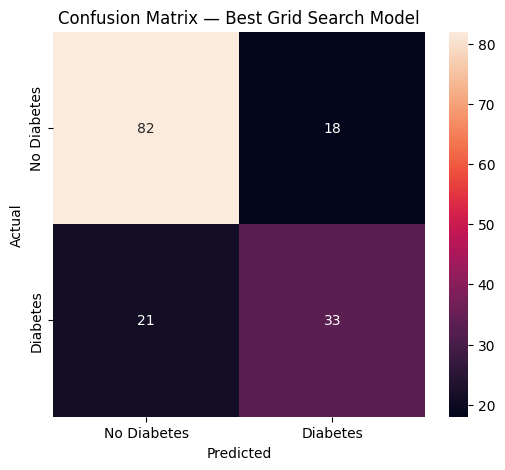

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Best Grid Search Model")
plt.show()